In [1]:
import re
import matplotlib.pyplot as plt

Emotion, Sentiments & Distortion Rules


In [2]:
#Emotion keywords
Emotions={"joy":{"happy","good","great","love","glad"},
          "sadness":{"sad","unhappy","down","depression"},
          "anger":{"angry","mad","furious","hate"},
         "fear":{"afraid","scared","worried","anxious"},}

#cognitive distortions
Distortions={"all_or_any": r"\b(always|sometime)\b", #regular expression (regex) pattern used to detect certain cognitive distortions in text.
  # \b is a regex symbol which match a word from text only when this is the start or end of a word.
             "dissapointed": r"\b(can't handel|disaster|ruined)\b",
             "negative_self_talk":r"\b(I am (bad|stupid|a failure))\b",
}

#sentiments
Positive = {"good","good", "great", "happy", "love", "okay"}
Negative = {"bad", "sad", "hate", "awful", "terrible"}

Analysis Function

In [3]:
def analyze_text(text):
    text_lower=text.lower()
    #words list
    words = re.findall(r"\w+",text_lower)
    #collecting setiments accordingly
    pos = sum(w in Positive for w in words)
    neg = sum(w in Negative for w in words)
    
    if pos > neg:
        sentiments = "positive"
    elif neg > pos:
        sentiments = "Negative"
    else:
        sentiments = "Neutral"

#Checking the Emotions
    feelings= {emo: sum(w in lex for w in words) 
               for emo, lex in Emotions.items()}
    max_val = max(feelings.values())  #The code counts emotional words in the text, finds which emotion appears most, and labels it as sadness, anger, fear, joy, or neutral

    dominant = [emo for emo , v in feelings.items() 
                if v == max_val and v>0]
    if not dominant:
        dominant = ["neutral"]

#cognizive Distortion
    distort = []
    for name, pattern in Distortions.items():
        if re.search(pattern,text_lower):
            distort.append(name)
    return{
        "sentiments": sentiments,
        "positive_count": pos,
        "negative_count": neg,
        "emotion_count": feelings,
        "dominant_emotion": dominant,
        "cognitive distortion": distort
    }

In [4]:
text = input("Enter some text to analyze: ")

result = analyze_text(text)

result


Enter some text to analyze:  I am a failure


{'sentiments': 'Neutral',
 'positive_count': 0,
 'negative_count': 0,
 'emotion_count': {'joy': 0, 'sadness': 0, 'anger': 0, 'fear': 0},
 'dominant_emotion': ['neutral'],
 'cognitive distortion': []}

In [11]:
#Sentiment plot
def plot_analysis(result):
    plt.figure(figsize = (5,3))
    plt.bar(["positive","negative"],
           [result["positive_count"],result["negative_count"]])
    plt.title("Sentiment Word Count")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()
    # emotion plot
    emotions = result["emotion_count"]
    plt.figure(figsize = (5,4))
    plt.bar(emotions.keys(), emotions.values())
    plt.title("Emotion Keyword Match")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.show()

Enter text to analyze:  I am happy, excited, positive


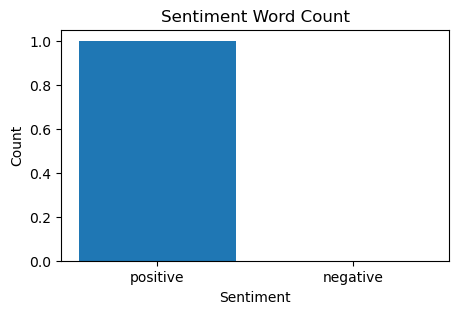

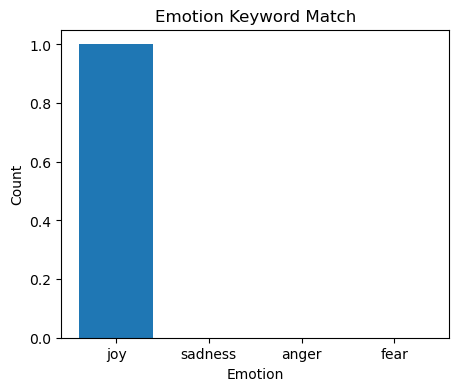

{'sentiments': 'positive',
 'positive_count': 1,
 'negative_count': 0,
 'emotion_count': {'joy': 1, 'sadness': 0, 'anger': 0, 'fear': 0},
 'dominant_emotion': ['joy'],
 'cognitive distortion': []}

In [12]:
text = input("Enter text to analyze: ")
result = analyze_text(text)

plot_analysis(result)

result
